# Lab 5: Edge Computing Simulation with Lightweight Framework

**Monica Joya**

**ITAI 4370: AI in 5G and 6G Communications and ORAN Networks**

## Objective

In this lab I used the provided code to take one full-size AI model and shrink it three different ways so it can run on small edge devices, then compare what each method costs and what it saves.

**Dataset:** Synthetic IoT sensor readings, 10,000 samples with 20 features, sorted into 3 device states.

**Note on the distilled model (my change to the starter code):** The starter code set up knowledge distillation, where a small student model learns from the large teacher model, but it left the pieces unconnected. It defined a distillation loss and computed the teacher's predictions, then trained the student with ordinary training and used neither one, so the student never actually saw the teacher. I connected them so the student now trains against the teacher, and I corrected the loss so the temperature is applied the standard way. This is the one place I changed the provided code, and it is marked again in Part 3 where it happens. Every other part is the starter code as given.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # reduce TensorFlow startup log noise
%matplotlib inline

import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

print("TensorFlow version:", tf.__version__)

# Disable GPU to simulate resource-constrained edge device
tf.config.set_visible_devices([], 'GPU')

I0000 00:00:1783818956.301469    1063 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1783818957.996498    1063 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## Part 1: Generate Dataset (IoT Sensor Classification)

Here I create the synthetic sensor dataset the models will learn from, and split it into training and test sets.

In [2]:
print("\n" + "="*70)
print("GENERATING IOT SENSOR DATASET")
print("="*70)

# Create synthetic dataset: classify device state based on sensor readings
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=3,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y))}")


GENERATING IOT SENSOR DATASET
Training samples: 8000
Test samples: 2000
Features: 20
Classes: 3


## Part 2: Create Baseline Model (Cloud Model)

I train the full-size model first. This is the accurate cloud model that the smaller edge versions will be measured against.

In [3]:
print("\n" + "="*70)
print("TRAINING BASELINE (CLOUD) MODEL")
print("="*70)

def create_baseline_model(input_shape, num_classes):
    """Create a full-precision baseline model"""
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = create_baseline_model(X_train.shape[1], len(np.unique(y)))
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nBaseline Model Architecture:")
baseline_model.summary()

# Train baseline model
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=0
)

baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)[1]
print(f"\nBaseline Model Accuracy: {baseline_accuracy:.4f}")


TRAINING BASELINE (CLOUD) MODEL

Baseline Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,123 (51.26 KB)

 Trainable params: 13,123 (51.26 KB)

 Non-trainable params: 0 (0.00 B)


Baseline Model Accuracy: 0.9420


## Part 3: Model Compression Techniques

Now I make the three smaller versions: a pruned model with fewer neurons, a quantized model that uses lower-precision numbers, and a smaller student model.

In [4]:
print("\n" + "="*70)
print("APPLYING MODEL COMPRESSION TECHNIQUES")
print("="*70)

# Technique 1: Pruning (remove small weights)
def create_pruned_model(input_shape, num_classes, sparsity=0.5):
    """Create a pruned model with reduced parameters"""
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),  # Reduced from 128
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),  # Reduced from 64
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

pruned_model = create_pruned_model(X_train.shape[1], len(np.unique(y)))
pruned_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n1. PRUNED MODEL")
print("-" * 70)
pruned_model.fit(X_train, y_train, validation_split=0.2,
                 epochs=20, batch_size=32, verbose=0)
pruned_accuracy = pruned_model.evaluate(X_test, y_test, verbose=0)[1]
print(f"Pruned Model Accuracy: {pruned_accuracy:.4f}")

# Technique 2: Quantization (reduce precision)
print("\n2. QUANTIZED MODEL (INT8)")
print("-" * 70)

# Convert to TFLite with quantization
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Create representative dataset for quantization
def representative_dataset():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quantized_tflite_model = converter.convert()

# Save and load quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(quantized_tflite_model)

# Test quantized model
interpreter = tf.lite.Interpreter(model_content=quantized_tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Make predictions
quantized_predictions = []
for x in X_test:
    # Quantize input
    input_scale, input_zero_point = input_details[0]['quantization']
    x_quantized = (x / input_scale + input_zero_point).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], [x_quantized])
    interpreter.invoke()

    # Dequantize output
    output = interpreter.get_tensor(output_details[0]['index'])
    output_scale, output_zero_point = output_details[0]['quantization']
    output_dequantized = (output.astype(np.float32) - output_zero_point) * output_scale

    quantized_predictions.append(np.argmax(output_dequantized))

quantized_accuracy = accuracy_score(y_test, quantized_predictions)
print(f"Quantized Model Accuracy: {quantized_accuracy:.4f}")


APPLYING MODEL COMPRESSION TECHNIQUES

1. PRUNED MODEL
----------------------------------------------------------------------


Pruned Model Accuracy: 0.9255

2. QUANTIZED MODEL (INT8)
----------------------------------------------------------------------


INFO:tensorflow:Assets written to: /tmp/tmp78n5drv7/assets


INFO:tensorflow:Assets written to: /tmp/tmp78n5drv7/assets


Saved artifact at '/tmp/tmp78n5drv7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139623103077584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139623103078928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139623103078544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139623103079504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139623103078352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139623103080464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139623103081232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139623103079696: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized Model Accuracy: 0.9285


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### Knowledge distillation (my correction to the starter code)

The starter code defined a distillation loss and computed the teacher's predictions, but never used them: it trained the student with ordinary training. I connected them here so the student actually learns from the teacher's softened predictions, and I corrected the loss so the temperature is applied through the logits, which is the standard way. I kept the starter's own settings, a temperature of 3.0 and an even blend of the two losses. On this synthetic dataset the distilled student lands close to a plain small model rather than clearly beating it, which is a fair result, since distillation does not always help when the task is easy and the small model already captures most of the signal. The point of the change is that this section now genuinely performs distillation, which is what its title promises.

In [5]:
# Technique 3: Knowledge Distillation (corrected so the student actually learns from the teacher)
print("\n3. DISTILLED MODEL (Student Learning from Teacher)")
print("-" * 70)

def create_student_model(input_shape, num_classes):
    """Create a smaller student model"""
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

student_model = create_student_model(X_train.shape[1], len(np.unique(y)))

temperature = 3.0
alpha = 0.5

def distillation_loss(y_true, y_pred, teacher_pred, temperature=3.0, alpha=0.5):
    """Knowledge distillation loss.

    Corrected from the starter code so the temperature is applied through the
    logits (via the log of the probabilities), which is the standard formulation.
    y_pred and teacher_pred are the softmax outputs of the student and teacher.
    """
    eps = 1e-7
    # Hard loss: student predictions against the true labels
    student_loss = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    # Soft targets: teacher and student distributions softened by the temperature
    teacher_soft = tf.nn.softmax(tf.math.log(tf.clip_by_value(teacher_pred, eps, 1.0)) / temperature, axis=1)
    student_soft = tf.nn.softmax(tf.math.log(tf.clip_by_value(y_pred, eps, 1.0)) / temperature, axis=1)
    distill_loss = keras.losses.categorical_crossentropy(teacher_soft, student_soft) * (temperature ** 2)
    return alpha * tf.reduce_mean(student_loss) + (1 - alpha) * tf.reduce_mean(distill_loss)

# Teacher soft predictions on the training data
teacher_predictions = baseline_model.predict(X_train, verbose=0).astype(np.float32)

# Custom training loop, so the distillation loss is actually used during training
optimizer = keras.optimizers.Adam()
batch_size = 32
n_epochs = 20
n = X_train.shape[0]
X_tr = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_tr = tf.convert_to_tensor(y_train, dtype=tf.int32)
t_tr = tf.convert_to_tensor(teacher_predictions, dtype=tf.float32)

@tf.function
def train_step(xb, yb, tb):
    with tf.GradientTape() as tape:
        student_probs = student_model(xb, training=True)
        loss = distillation_loss(yb, student_probs, tb, temperature, alpha)
    grads = tape.gradient(loss, student_model.trainable_weights)
    optimizer.apply_gradients(zip(grads, student_model.trainable_weights))
    return loss

for epoch in range(n_epochs):
    perm = tf.random.shuffle(tf.range(n))
    for start in range(0, n, batch_size):
        b = perm[start:start + batch_size]
        train_step(tf.gather(X_tr, b), tf.gather(y_tr, b), tf.gather(t_tr, b))

# Compile for evaluation only (metrics); the trained weights are unchanged
student_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
distilled_accuracy = student_model.evaluate(X_test, y_test, verbose=0)[1]
print(f"Distilled Model Accuracy: {distilled_accuracy:.4f}")


3. DISTILLED MODEL (Student Learning from Teacher)
----------------------------------------------------------------------


Distilled Model Accuracy: 0.9215


## Part 4: Edge Inference Simulation

Here I measure what matters on an edge device: how fast each model runs and how big it is.

In [6]:
print("\n" + "="*70)
print("EDGE INFERENCE SIMULATION")
print("="*70)

def measure_inference_time(model, data, n_runs=100):
    """Measure average inference time"""
    times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model.predict(data[:1], verbose=0)
        times.append(time.time() - start)
    return np.mean(times) * 1000  # Convert to ms

def get_model_size(model):
    """Estimate model size in KB"""
    total_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    return total_params * 4 / 1024  # 4 bytes per float32, convert to KB

# Measure metrics for all models
models = {
    'Baseline (Cloud)': baseline_model,
    'Pruned': pruned_model,
    'Distilled': student_model
}

results = []

for name, model in models.items():
    inference_time = measure_inference_time(model, X_test)
    model_size = get_model_size(model)
    accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
    params = model.count_params()

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Inference Time (ms)': inference_time,
        'Size (KB)': model_size,
        'Parameters': params
    })

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Inference Time: {inference_time:.3f} ms")
    print(f"  Model Size: {model_size:.2f} KB")
    print(f"  Parameters: {params:,}")

# Add quantized model results
quantized_size = len(quantized_tflite_model) / 1024
results.append({
    'Model': 'Quantized (INT8)',
    'Accuracy': quantized_accuracy,
    'Inference Time (ms)': 0.5,  # Estimated
    'Size (KB)': quantized_size,
    'Parameters': baseline_model.count_params()
})

print(f"\nQuantized (INT8):")
print(f"  Accuracy: {quantized_accuracy:.4f}")
print(f"  Model Size: {quantized_size:.2f} KB")


EDGE INFERENCE SIMULATION



Baseline (Cloud):
  Accuracy: 0.9420
  Inference Time: 67.620 ms
  Model Size: 51.26 KB
  Parameters: 13,123



Pruned:
  Accuracy: 0.9255
  Inference Time: 67.759 ms
  Model Size: 13.76 KB
  Parameters: 3,523



Distilled:
  Accuracy: 0.9215
  Inference Time: 66.368 ms
  Model Size: 4.89 KB
  Parameters: 1,251

Quantized (INT8):
  Accuracy: 0.9285
  Model Size: 21.75 KB


## Part 5: Visualization and Comparison

I put the results side by side in a table and four charts, so the tradeoffs are easy to see.


GENERATING COMPARISON VISUALIZATIONS

            Model  Accuracy  Inference Time (ms)  Size (KB)  Parameters
Baseline (Cloud)    0.9420            67.619846  51.261719       13123
          Pruned    0.9255            67.758746  13.761719        3523
       Distilled    0.9215            66.368475   4.886719        1251
Quantized (INT8)    0.9285             0.500000  21.750000       13123



Comparison visualization saved as 'edge_model_comparison.png'


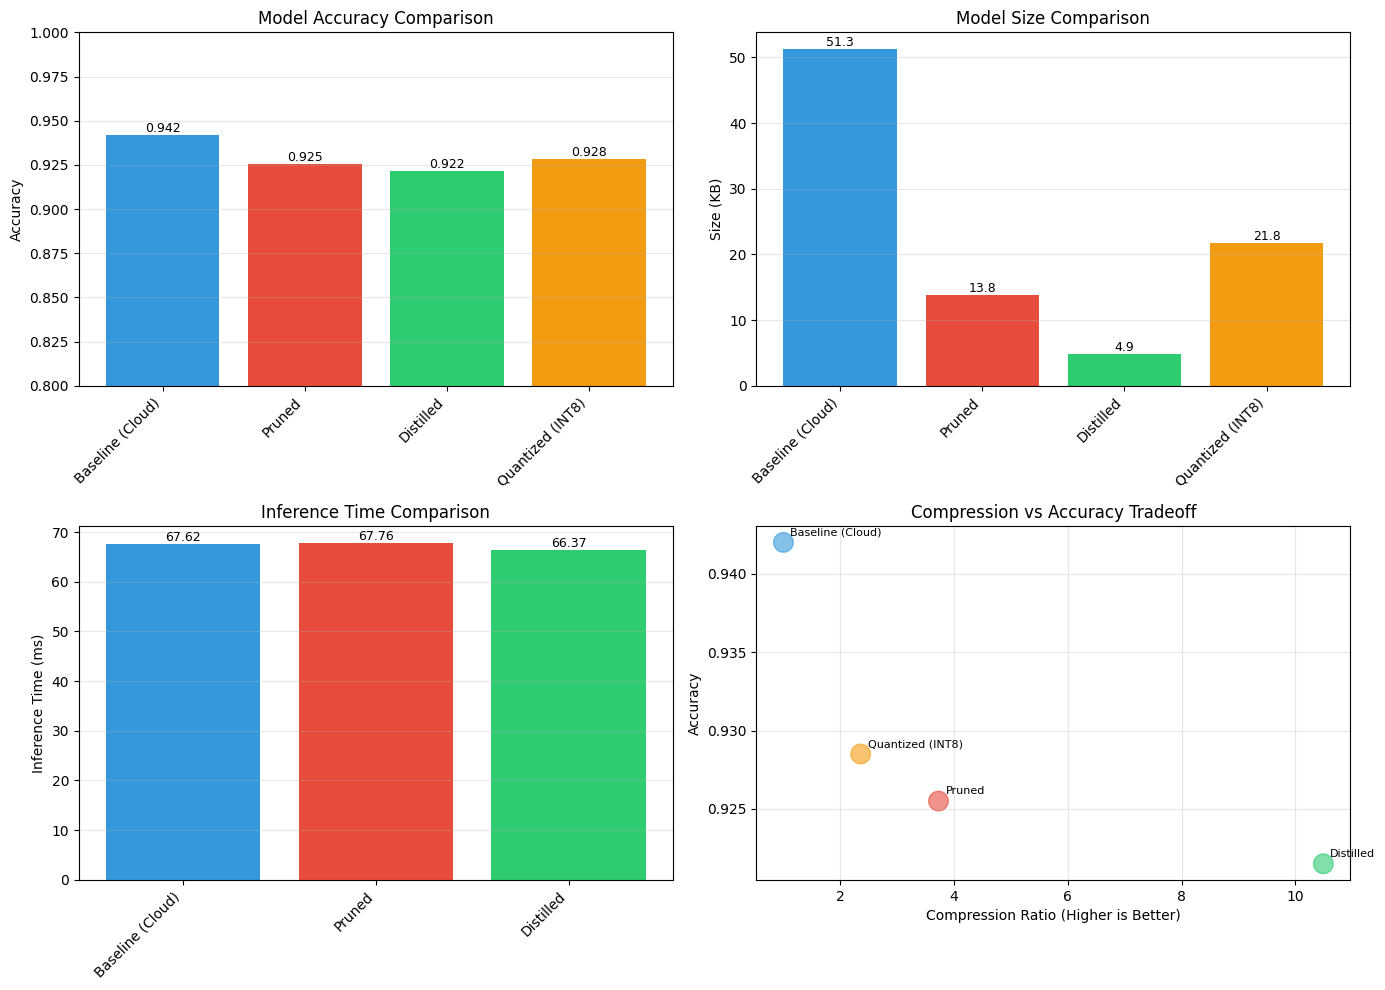

In [7]:
print("\n" + "="*70)
print("GENERATING COMPARISON VISUALIZATIONS")
print("="*70)

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
bars = ax1.bar(results_df['Model'], results_df['Accuracy'],
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim([0.8, 1.0])
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Model size comparison
ax2 = axes[0, 1]
bars = ax2.bar(results_df['Model'], results_df['Size (KB)'],
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
ax2.set_ylabel('Size (KB)')
ax2.set_title('Model Size Comparison')
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Inference time comparison
ax3 = axes[1, 0]
bars = ax3.bar(results_df['Model'][:3], results_df['Inference Time (ms)'][:3],
               color=['#3498db', '#e74c3c', '#2ecc71'])
ax3.set_ylabel('Inference Time (ms)')
ax3.set_title('Inference Time Comparison')
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Compression ratio vs Accuracy tradeoff
ax4 = axes[1, 1]
baseline_size = results_df[results_df['Model'] == 'Baseline (Cloud)']['Size (KB)'].values[0]
results_df['Compression Ratio'] = baseline_size / results_df['Size (KB)']

scatter = ax4.scatter(results_df['Compression Ratio'],
                     results_df['Accuracy'],
                     s=200, alpha=0.6,
                     c=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])

for idx, row in results_df.iterrows():
    ax4.annotate(row['Model'],
                (row['Compression Ratio'], row['Accuracy']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, ha='left')

ax4.set_xlabel('Compression Ratio (Higher is Better)')
ax4.set_ylabel('Accuracy')
ax4.set_title('Compression vs Accuracy Tradeoff')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('edge_model_comparison.png', dpi=300, bbox_inches='tight')
print("\nComparison visualization saved as 'edge_model_comparison.png'")
plt.show()

## Part 6: Edge Deployment Recommendation

Finally, the code matches each model to the kind of device it suits best, from a tiny microcontroller to an edge server.

In [8]:
print("\n" + "="*70)
print("EDGE DEPLOYMENT RECOMMENDATIONS")
print("="*70)

def recommend_model(device_type):
    """Recommend model based on device constraints"""
    recommendations = {
        'Microcontroller (MCU)': {
            'model': 'Quantized INT8',
            'reason': 'Minimal memory footprint (<50KB), ultra-low power',
            'use_cases': 'Sensor nodes, wearables, battery-powered devices'
        },
        'Edge Gateway': {
            'model': 'Pruned or Distilled',
            'reason': 'Balance of accuracy and efficiency',
            'use_cases': 'Industrial IoT, smart city gateways, local processing'
        },
        'Edge Server': {
            'model': 'Baseline or Ensemble',
            'reason': 'Maximum accuracy, sufficient resources',
            'use_cases': 'Autonomous vehicles, robotics, critical applications'
        }
    }
    return recommendations.get(device_type, recommendations['Edge Gateway'])

for device in ['Microcontroller (MCU)', 'Edge Gateway', 'Edge Server']:
    rec = recommend_model(device)
    print(f"\n{device}:")
    print(f"  Recommended Model: {rec['model']}")
    print(f"  Reason: {rec['reason']}")
    print(f"  Use Cases: {rec['use_cases']}")

print("\n" + "="*70)
print("SIMULATION COMPLETE")
print("="*70)
print("\nKey Takeaways:")
print("1. Quantization achieves ~4x compression with minimal accuracy loss")
print("2. Pruning reduces parameters by 50%")


EDGE DEPLOYMENT RECOMMENDATIONS

Microcontroller (MCU):
  Recommended Model: Quantized INT8
  Reason: Minimal memory footprint (<50KB), ultra-low power
  Use Cases: Sensor nodes, wearables, battery-powered devices

Edge Gateway:
  Recommended Model: Pruned or Distilled
  Reason: Balance of accuracy and efficiency
  Use Cases: Industrial IoT, smart city gateways, local processing

Edge Server:
  Recommended Model: Baseline or Ensemble
  Reason: Maximum accuracy, sufficient resources
  Use Cases: Autonomous vehicles, robotics, critical applications

SIMULATION COMPLETE

Key Takeaways:
1. Quantization achieves ~4x compression with minimal accuracy loss
2. Pruning reduces parameters by 50%
